In [1]:
import pandas as pd

df = pd.read_csv('train (1).csv')

In [2]:
df

,id,dataset_id,title,content,classification
0,341cc34c0994933,2.0,Donald Trump pide que le encadenen en el sótan...,Donald Trump pide que le encadenen en el sótan...,real
1,3be5da55eb2ec93,2.0,Mattis says will try to work with Pakistan 'on...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,fake
2,gossipcop-890602,0.0,Bette Midler slams 'cheap' Hocus Pocus remake,NaN,real
3,de0a97e74559c40,1.0,SUNDAY SCREENING: The Deep State: Hiding in Pl...,Our weekly documentary screening curated by th...,fake
4,e4efe68210fc475,2.0,Ping-Pong as the Fountain of Youth - The New Y...,"I returned home the other night exhausted, qua...",fake
...,...,...,...,...,...
149044,90df729c97b86af,5.0,NIH study validates decontamination methods fo...,n95 respirators can be decontaminated effectiv...,real
149045,8630.json,4.0,"Even after collective bargaining reforms, most...",NaN,real
149046,2079723346611be,2.0,Paul Craig Roberts: ‘By Cooperating with Washi...,By Paul Crag RobertsA month ago I wrote a colu...,real
149047,75e8aaa299ee19d,2.0,China says has made best effort on North Korea...,BEIJING (Reuters) - A senior Chinese diplomat ...,fake


In [3]:
# Shape before dropping
print(f"Original Shape: {df.shape}")

df.dropna(subset=['content'], inplace=True)

# After dropping
print(f"Shape after dropping: {df.shape}")

Original Shape: (149049, 5)
Shape after dropping: (114522, 5)


# Data Cleaning

In [4]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [6]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# BASIC CLEANING
def basic_clean(text):
    return str(text).lower().strip()

# ADVANCED CLEANING
def advanced_clean(text):
    # 1. Lowercase
    text = str(text).lower()

    # 2. Replace URLs with [Link]
    text = re.sub(r'http\S+|www\S+|https\S+', '[Link]', text, flags=re.MULTILINE)

    # 3. Replace Numbers with [Number]
    text = re.sub(r'\d+', '[Number]', text)

    # 4. Remove special characters (keep only words and our special tokens)
    text = re.sub(r'[^a-zA-Z\s\[\]]', '', text)

    # 5. Tokenization (split by whitespace)
    words = text.split()

    # 6. Remove Stopwords & Lemmatization
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(cleaned_words)

# Creating a Balanced Sample
Running PCA on the full 150k dataset would crash the RAM because it requires converting a massive sparse matrix into a dense array.

To avoid this, we create a stratified sample of 5,000 rows.


* 5,000 is large enough to see clear clusters but small enough to run in seconds.
* We ensure an exact 50/50 split between Real and Fake news so our visualization isn't biased.





Counts per class in sample:
classification
fake    2500
real    2500
Name: count, dtype: int64


/tmp/ipython-input-2044958476.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('classification', group_keys=False).apply(lambda x: x.sample(min(len(x), SAMPLE_SIZE // 2)))
/tmp/ipython-input-2044958476.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_sample['classification'], palette={'real': 'blue', 'fake': 'orange'})


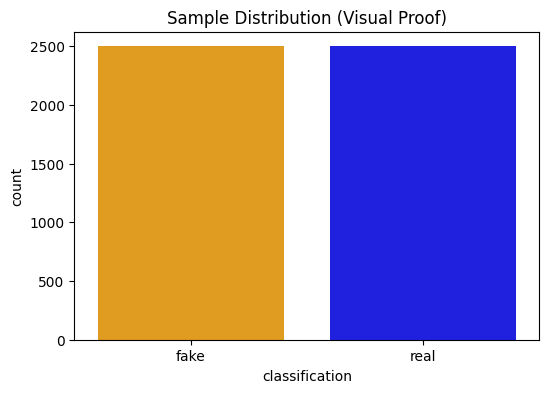

Sample created with shape: (5000, 5)


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Take a random sample of 5,000 rows (balanced by class)
SAMPLE_SIZE = 5000
df_sample = df.groupby('classification', group_keys=False).apply(lambda x: x.sample(min(len(x), SAMPLE_SIZE // 2)))

# Get the exact counts
counts = df_sample['classification'].value_counts()
print("Counts per class in sample:")
print(counts)

# Visual Proof (Bar Chart)
plt.figure(figsize=(6, 4))
sns.countplot(x=df_sample['classification'], palette={'real': 'blue', 'fake': 'orange'})
plt.title("Sample Distribution (Visual Proof)")
plt.show()

print(f"Sample created with shape: {df_sample.shape}")

In [8]:
# Clean the SAMPLE only
df_sample['clean_basic'] = df_sample['content'].apply(basic_clean)
df_sample['clean_advanced'] = df_sample['content'].apply(advanced_clean)

print("Cleaning done.")

Cleaning done.


# Vectorization and PCA

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

def visualize_separation(data_column, title):

    # 1. Vectorize (TF-IDF) - Limit to 3000 features for speed
    tfidf = TfidfVectorizer(max_features=3000)
    matrix = tfidf.fit_transform(data_column)

    # 2. PCA (Reduce to 2D)
    dense_matrix = matrix.toarray()
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(dense_matrix)

    # 3. Plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=pca_result[:, 0],
        y=pca_result[:, 1],
        hue=df_sample['classification'],
        alpha=0.6,
        palette={'real': 'blue', 'fake': 'red'}
    )
    plt.title(f'{title}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Classification')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print stats
    print(f"Variance Ratio: {pca.explained_variance_ratio_}")
    print("-" * 30)

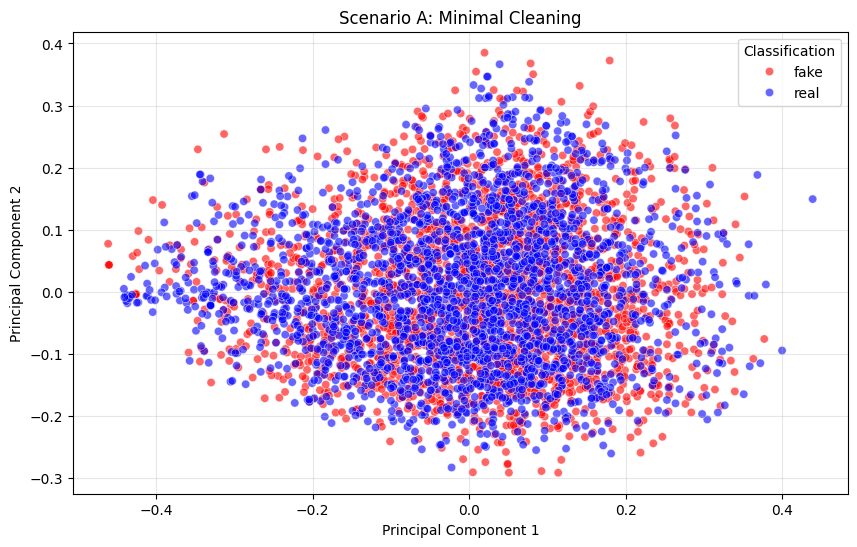

Variance Ratio: [0.02787601 0.01766618]
------------------------------


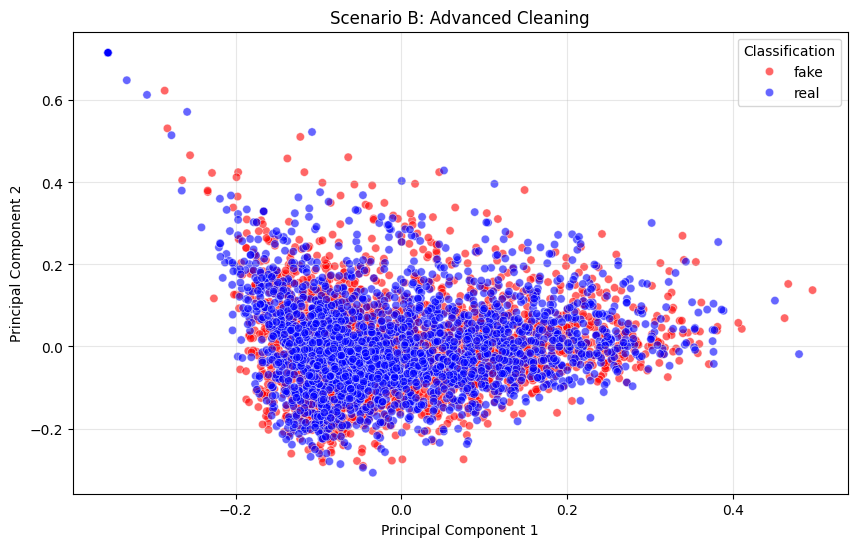

Variance Ratio: [0.01588134 0.0140035 ]
------------------------------


In [14]:
# Plot 1: Minimal Cleaning
visualize_separation(df_sample['clean_basic'], "Scenario A: Minimal Cleaning")

# Plot 2: Advanced Cleaning
visualize_separation(df_sample['clean_advanced'], "Scenario B: Advanced Cleaning")

# Vectorization Technique Analysis

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

# We compare TF-IDF against a standard Bag-of-Words (CountVectorizer)
# to see which one handles the variance better.

print("Running Vectorization Experiment on Sample...")

# 1. Bag-of-Words (Simple Counts)
bow_vect = CountVectorizer(max_features=3000)
bow_matrix = bow_vect.fit_transform(df_sample['clean_advanced'])
pca_bow = PCA(n_components=2)
pca_bow.fit(bow_matrix.toarray())

# 2. TF-IDF (Weighted)
tfidf_vect = TfidfVectorizer(max_features=3000)
tfidf_matrix = tfidf_vect.fit_transform(df_sample['clean_advanced'])
pca_tfidf = PCA(n_components=2)
pca_tfidf.fit(tfidf_matrix.toarray())

# Print Results
print(f"\nExplained Variance (Bag-of-Words): {sum(pca_bow.explained_variance_ratio_):.2%}")
print(f"Explained Variance (TF-IDF):     {sum(pca_tfidf.explained_variance_ratio_):.2%}")

print("\nINTERPRETATION:")
if sum(pca_bow.explained_variance_ratio_) > sum(pca_tfidf.explained_variance_ratio_):
    print("BoW has higher variance, likely driven by document length (noise).")
    print("TF-IDF has lower variance because it normalizes length and focuses on content.")

Running Vectorization Experiment on Sample...

Explained Variance (Bag-of-Words): 35.03%
Explained Variance (TF-IDF):     2.99%

INTERPRETATION:
BoW has higher variance, likely driven by document length (noise).
TF-IDF has lower variance because it normalizes length and focuses on content.


In [16]:
!pip install gensim

Training Word2Vec Model on sample data...
Explained Variance (Word2Vec): 44.44%


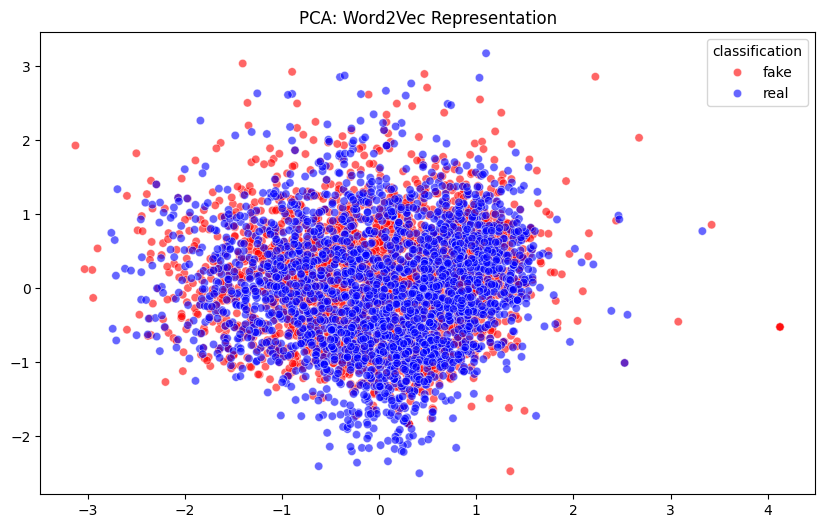

In [17]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

print("Training Word2Vec Model on sample data...")

# 1. Prepare Data (Word2Vec needs a list of lists of words)
# We use the 'clean_advanced' column we already created
sentences = [text.split() for text in df_sample['clean_advanced']]

# 2. Train the Model
# vector_size=100: Each word will be a list of 100 numbers
# window=5: Look at 5 words to the left and right for context
# min_count=1: Don't ignore rare words (since our sample is small)
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

# 3. Vectorize Documents (Average the words)
# Word2Vec gives us a vector for "King", "Man", etc.
# To get a vector for a whole ARTICLE, we usually just average all the words in it.
def get_document_vector(doc):
    # Get vectors for all words that are in the model
    vectors = [w2v_model.wv[word] for word in doc if word in w2v_model.wv]

    if len(vectors) > 0:
        return np.mean(vectors, axis=0) # Average them
    else:
        return np.zeros(100) # If doc is empty, return zeros

# Apply to all docs
# This creates a matrix of size (5000 rows x 100 columns)
doc_vectors = np.array([get_document_vector(doc) for doc in sentences])

# 4. Run PCA
pca_w2v = PCA(n_components=2)
pca_w2v.fit(doc_vectors)

print(f"Explained Variance (Word2Vec): {sum(pca_w2v.explained_variance_ratio_):.2%}")

# Plot
plt.figure(figsize=(10, 6))
pca_result = pca_w2v.transform(doc_vectors)
sns.scatterplot(
    x=pca_result[:, 0],
    y=pca_result[:, 1],
    hue=df_sample['classification'],
    alpha=0.6,
    palette={'real': 'blue', 'fake': 'red'}
)
plt.title('PCA: Word2Vec Representation')
plt.show()

In [13]:
# Create a temporary dataframe with the PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['label'] = df_sample['classification'].values

# Calculate the average X-value (PC1) for each class
centroids = pca_df.groupby('label')['PC1'].mean()
print(centroids)

label
fake   -0.0297
real    0.0297
Name: PC1, dtype: float64


# Processing the whole dataset

In [14]:
# Load the FULL dataset (150k rows)
df_full = pd.read_csv('train (1).csv')
print(f"Full dataset loaded: {df_full.shape}")

df_full

Full dataset loaded: (149049, 5)


,id,dataset_id,title,content,classification
0,341cc34c0994933,2.0,Donald Trump pide que le encadenen en el sótan...,Donald Trump pide que le encadenen en el sótan...,real
1,3be5da55eb2ec93,2.0,Mattis says will try to work with Pakistan 'on...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,fake
2,gossipcop-890602,0.0,Bette Midler slams 'cheap' Hocus Pocus remake,NaN,real
3,de0a97e74559c40,1.0,SUNDAY SCREENING: The Deep State: Hiding in Pl...,Our weekly documentary screening curated by th...,fake
4,e4efe68210fc475,2.0,Ping-Pong as the Fountain of Youth - The New Y...,"I returned home the other night exhausted, qua...",fake
...,...,...,...,...,...
149044,90df729c97b86af,5.0,NIH study validates decontamination methods fo...,n95 respirators can be decontaminated effectiv...,real
149045,8630.json,4.0,"Even after collective bargaining reforms, most...",NaN,real
149046,2079723346611be,2.0,Paul Craig Roberts: ‘By Cooperating with Washi...,By Paul Crag RobertsA month ago I wrote a colu...,real
149047,75e8aaa299ee19d,2.0,China says has made best effort on North Korea...,BEIJING (Reuters) - A senior Chinese diplomat ...,fake


In [15]:
# Advanced Cleaning
df_full['clean_text'] = df_full['content'].apply(advanced_clean)

# Save the Cleaned Data
df_full[['id', 'title', 'clean_text', 'classification']].to_csv('training_cleaned_full.csv', index=False)